# 作业一

## 一. 训练随机森林模型

使用米筐数据获取沪深300成份股的财务报表比率，基于随机森林模型预测下一年业绩是否较当前年度改善。

标签定义：若下一年度的核心业绩指标较当前年度上升，则记为 1，否则为 0。默认优先使用 `net_profit_yoy`，若该字段不可用则自动退回到其他可用的成长类指标。

### 1. 导入库

In [1]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

# 保存与加载模型所用库
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

# 屏蔽不必要的警告以保持输出整洁
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

# 尝试导入并初始化米筐数据客户端 rqdatac，用于获取指数和财务因子数据
try:
    import rqdatac
except ImportError as exc:
    raise ImportError("请先安装 rqdatac：pip install rqdatac") from exc

# 初始化 rqdatac（可能需要账号授权），失败时打印错误但继续执行以便调试
try:
    rqdatac.init()
    print("RQData 连接成功")
except Exception as exc:
    print("RQData 连接失败，请检查账号、网络或授权：", exc)

# 输出目录与文件路径：模型、特征说明、预测结果
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_PATH = OUTPUT_DIR / "hs300_rf_classifier.joblib"
FEATURE_PATH = OUTPUT_DIR / "hs300_rf_features.json"
PREDICTION_PATH = OUTPUT_DIR / "hs300_latest_predictions.csv"

RQData 连接成功


In [2]:
from pathlib import Path

def _load_local_env(env_path: str | Path = '.env') -> None:
    path = Path(env_path)
    if not path.exists():
        return

    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('\"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value

_load_local_env()
print('已检查本地 .env 文件（如存在则自动加载）。')

已检查本地 .env 文件（如存在则自动加载）。


### 2. 获取沪深300成份股列表

从米筐数据获取沪深300指数成份股及其历史调整信息，按年末样本构建股票池，避免未来数据泄露。

In [3]:
# 指数代码与年份范围：使用沪深300，样本从 START_YEAR 开始，END_YEAR 为当前年的前一年
INDEX_CODE = "000300.XSHG"
START_YEAR = 2012
END_YEAR = pd.Timestamp.today().year - 1

# 返回给定年份的最后一个交易日（用于避免使用未来数据点）
def last_trading_day_of_year(year: int) -> pd.Timestamp:
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    try:
        dates = rqdatac.get_trading_dates(start, end)
        if len(dates) > 0:
            return pd.Timestamp(dates[-1])
    except Exception:
        pass
    return pd.Timestamp(end)

# 获取给定年份（按年末）的沪深300成分股列表，返回已排序的列表；出错返回空列表
def get_hs300_components_by_year(year: int) -> list[str]:
    report_date = last_trading_day_of_year(year)
    try:
        components = rqdatac.index_components(INDEX_CODE, report_date)
        return sorted(list(components))
    except Exception as exc:
        print(f"获取 {year} 年成份股失败：{exc}")
        return []

year_component_map = {year: get_hs300_components_by_year(year) for year in range(START_YEAR, END_YEAR + 1)}
sample_sizes = pd.Series({year: len(stocks) for year, stocks in year_component_map.items()}, name="constituent_count")
display(sample_sizes.to_frame())

,constituent_count
2012,300
2013,300
2014,300
2015,300
2016,300
2017,300
2018,300
2019,300
2020,300
2021,300


### 3. 提取财务报表比率数据

优先从米筐财务指标表中提取盈利能力、偿债能力、运营能力和成长能力相关指标。

In [4]:
# 定义标准特征到候选因子名的映射：按优先级列出可能的字段名称，resolve_factor_fields 会选择可用字段
FACTOR_ALIASES = {
    "roe": ["return_on_equity_diluted_ttm", "return_on_equity_ttm", "return_on_equity_diluted_lyr"],
    "roa": ["return_on_asset_ttm", "return_on_asset_net_profit_ttm", "return_on_asset_lyr"],
    "gross_profit_margin": ["gross_profit_margin_ttm", "gross_profit_margin_lyr"],
    "net_profit_margin": ["net_profit_margin_ttm", "net_profit_margin_lyr"],
    "current_ratio": ["current_ratio_ttm", "current_ratio_lf", "current_ratio_lyr"],
    "quick_ratio": ["quick_ratio_ttm", "quick_ratio_lf", "quick_ratio_lyr"],
    "debt_to_assets": ["debt_to_asset_ratio_ttm", "debt_to_asset_ratio_lf", "debt_to_asset_ratio_lyr"],
    "asset_turnover": ["total_asset_turnover_ttm", "total_asset_turnover_lyr"],
    "inventory_turnover": ["inventory_turnover_ttm", "inventory_turnover_lyr"],
    "accounts_receivable_turnover": ["account_receivable_turnover_rate_ttm", "account_receivable_turnover_rate_lyr"],
    "operating_cash_flow_to_current_liabilities": ["ocf_to_current_ratio_ttm", "ocf_to_current_ratio_lyr"],
    "revenue_yoy": ["operating_revenue_growth_ratio_ttm", "operating_revenue_growth_ratio_lyr", "inc_revenue_ttm", "inc_revenue_lyr"],
    "net_profit_yoy": ["net_profit_parent_company_growth_ratio_ttm", "net_profit_growth_ratio_ttm", "net_profit_parent_company_growth_ratio_lyr", "net_profit_growth_ratio_lyr"],
    "total_asset_growth_rate": ["total_asset_growth_ratio_ttm", "total_asset_growth_ratio_lyr"],
}

# 在可用因子列表中匹配我们关心的字段，返回标准名->实际字段名的映射
def resolve_factor_fields() -> dict[str, str]:
    all_factors = set(rqdatac.get_all_factor_names())
    selected = {}
    for standard_name, candidates in FACTOR_ALIASES.items():
        for candidate in candidates:
            if candidate in all_factors:
                selected[standard_name] = candidate
                break
    return selected

SELECTED_FACTORS = resolve_factor_fields()
if not SELECTED_FACTORS:
    raise ValueError("未匹配到可用财务因子字段，请检查账号权限或因子库可用性。")

FEATURE_COLUMNS = list(SELECTED_FACTORS.keys())
TARGET_METRIC = "net_profit_yoy" if "net_profit_yoy" in FEATURE_COLUMNS else FEATURE_COLUMNS[-1]

# 打印映射关系与选择的标签参考指标，帮助调试和审阅字段匹配结果
print("标准特征 -> 实际因子映射：")
for k, v in SELECTED_FACTORS.items():
    print(f"  {k} <- {v}")
print("标签参考指标：", TARGET_METRIC)

# 从 rqdatac 因子接口按样本股票池和报告日抓取当期因子值，格式化列名并返回面板数据
def fetch_indicator_panel(year: int, stock_list: list[str]) -> pd.DataFrame:
    if not stock_list:
        return pd.DataFrame()

    report_date = last_trading_day_of_year(year)
    factor_list = list(SELECTED_FACTORS.values())

    # 仅请求 report_date 的因子快照，异常时返回空表并打印错误
    try:
        factor_df = rqdatac.get_factor(
            order_book_ids=stock_list,
            factor=factor_list,
            start_date=report_date,
            end_date=report_date,
        )
    except Exception as exc:
        print(f"提取 {year} 年财务因子失败：{exc}")
        return pd.DataFrame()

    if factor_df is None or len(factor_df) == 0:
        # 无数据时返回空 DataFrame
        return pd.DataFrame()

    # 将 MultiIndex 或其他索引转为列，并保证存在 order_book_id 列以便后续合并
    frame = factor_df.reset_index()
    if "order_book_id" not in frame.columns:
        # 兼容极少数返回格式
        idx_name = frame.columns[0]
        frame = frame.rename(columns={idx_name: "order_book_id"})

    # 把实际因子字段名映射回我们定义的标准特征名，方便后续统一处理
    reverse_map = {v: k for k, v in SELECTED_FACTORS.items()}
    frame = frame.rename(columns=reverse_map)

    if "date" in frame.columns:
        frame = frame.drop(columns=["date"])

    # 标记报告年份与报告日并返回格式化后的面板行
    frame["report_year"] = year
    frame["report_date"] = report_date
    return frame

panel_frames = []
for year, stock_pool in year_component_map.items():
    frame = fetch_indicator_panel(year, stock_pool)
    if not frame.empty:
        panel_frames.append(frame)

raw_panel = pd.concat(panel_frames, ignore_index=True) if panel_frames else pd.DataFrame()
display(raw_panel.head())
print("原始面板形状：", raw_panel.shape)

标准特征 -> 实际因子映射：
  roe <- return_on_equity_diluted_ttm
  roa <- return_on_asset_ttm
  gross_profit_margin <- gross_profit_margin_ttm
  net_profit_margin <- net_profit_margin_ttm
  current_ratio <- current_ratio_ttm
  quick_ratio <- quick_ratio_ttm
  debt_to_assets <- debt_to_asset_ratio_ttm
  asset_turnover <- total_asset_turnover_ttm
  inventory_turnover <- inventory_turnover_ttm
  accounts_receivable_turnover <- account_receivable_turnover_rate_ttm
  operating_cash_flow_to_current_liabilities <- ocf_to_current_ratio_ttm
  revenue_yoy <- operating_revenue_growth_ratio_ttm
  net_profit_yoy <- net_profit_parent_company_growth_ratio_ttm
  total_asset_growth_rate <- total_asset_growth_ratio_ttm
标签参考指标： net_profit_yoy


,order_book_id,roe,roa,gross_profit_margin,net_profit_margin,current_ratio,quick_ratio,debt_to_assets,asset_turnover,inventory_turnover,accounts_receivable_turnover,operating_cash_flow_to_current_liabilities,revenue_yoy,net_profit_yoy,total_asset_growth_rate,report_year,report_date
0,601369.XSHG,0.189937,0.073239,0.344477,0.168422,1.396126,1.022531,0.633974,0.412782,2.372265,3.685305,0.073460,0.221744,0.248659,0.164795,2012,2012-12-31
1,000401.XSHE,0.030067,0.038049,0.244843,0.018353,0.671285,0.418889,0.669214,0.370619,4.337366,12.022618,0.043879,-0.019760,-0.799207,0.210969,2012,2012-12-31
2,002415.XSHE,0.257281,0.245136,0.488818,0.281793,5.841510,5.050047,0.152814,0.773696,3.908473,4.933002,1.028823,0.409549,0.462215,0.252215,2012,2012-12-31
3,000703.XSHE,0.082640,0.060528,0.051753,0.022138,0.820171,0.487446,0.686814,1.466764,9.910238,67.839814,0.180122,-0.194162,-0.878302,0.645270,2012,2012-12-31
4,600895.XSHG,0.093934,0.063179,0.539940,0.296751,1.223479,0.422462,0.629356,0.112272,0.160494,1.712854,0.086936,0.924952,14.265396,0.018430,2012,2012-12-31


原始面板形状： (4200, 17)


### 4. 构建下一年业绩变化标签

根据当前年度与下一年度的核心业绩指标差值构造监督学习标签。这里定义为：下一年度指标较当前年度改善，则标签为 1，否则为 0。

In [5]:
# 检查是否成功抓取到原始面板数据，若为空则抛出错误提示
if raw_panel.empty:
    raise ValueError("未获取到任何财务指标数据，请检查米筐账号、网络或字段名。")

# 验证构建标签所需的关键列存在：股票标识、报告年度以及选定的目标指标
required_columns = ["order_book_id", "report_year", TARGET_METRIC]
missing_required = [col for col in required_columns if col not in raw_panel.columns]
if missing_required:
    raise ValueError(f"缺少构造标签所需字段：{missing_required}")

# 按股票与年度排序，并取下一年同一股票的指标作为比较基准，计算差值并构造二分类标签
ordered_panel = raw_panel.sort_values(["order_book_id", "report_year"]).copy()
ordered_panel["next_report_year"] = ordered_panel.groupby("order_book_id")["report_year"].shift(-1)
ordered_panel["next_metric"] = ordered_panel.groupby("order_book_id")[TARGET_METRIC].shift(-1)
ordered_panel["performance_delta"] = ordered_panel["next_metric"] - ordered_panel[TARGET_METRIC]
ordered_panel["label"] = (ordered_panel["performance_delta"] > 0).astype("float")

# 只保留相邻年份（report_year 与 next_report_year 恰好相差 1 年）的样本，删除含缺失值的记录并把标签转为整数
supervised = ordered_panel.loc[
    ordered_panel["next_report_year"] == ordered_panel["report_year"] + 1
].copy()
supervised = supervised.dropna(subset=[TARGET_METRIC, "next_metric", "label"]).copy()
supervised["label"] = supervised["label"].astype(int)

display(supervised[["order_book_id", "report_year", TARGET_METRIC, "next_metric", "performance_delta", "label"]].head())
print("监督学习样本数：", supervised.shape[0])
print("正样本占比：", supervised["label"].mean().round(4))

,order_book_id,report_year,net_profit_yoy,next_metric,performance_delta,label
88,000001.XSHE,2012,0.392147,0.158496,-0.233652,0
384,000001.XSHE,2013,0.158496,0.293837,0.135341,1
681,000001.XSHE,2014,0.293837,0.136201,-0.157636,0
974,000001.XSHE,2015,0.136201,0.045588,-0.090613,0
1274,000001.XSHE,2016,0.045588,0.008274,-0.037314,0


监督学习样本数： 3142
正样本占比： 0.4201


### 5. 清洗数据与特征工程

处理缺失值、无穷值、重复值和异常值，并补充简单的衍生特征。随机森林不需要特征标准化，因此这里重点做稳健清洗。

In [6]:
# 元数据列集合：这些列不作为模型特征，仅用于索引和标签构造
metadata_columns = {
    "order_book_id",
    "report_year",
    "report_date",
    "next_report_year",
    "next_metric",
    "performance_delta",
    "label",
}

# 选择数值型列作为候选特征，排除元数据列，并确保列存在于数据中
numeric_columns = supervised.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [col for col in numeric_columns if col not in metadata_columns]
feature_candidates = [col for col in feature_candidates if col in supervised.columns]

# 基础清洗：复制数据、把无穷值替换为 NaN、去重（按股票+年份）
clean_df = supervised.copy()
clean_df[feature_candidates] = clean_df[feature_candidates].replace([np.inf, -np.inf], np.nan)
clean_df = clean_df.drop_duplicates(subset=["order_book_id", "report_year"]).copy()

# 对每个候选特征进行 1%/99% 分位数裁剪以减弱极端值的影响
for col in feature_candidates:
    lower = clean_df[col].quantile(0.01)
    upper = clean_df[col].quantile(0.99)
    clean_df[col] = clean_df[col].clip(lower=lower, upper=upper)

# 根据现有列构造简单衍生特征（例如流动性缺口和 ROE 与杠杆比）以增强信息量
if {"current_ratio", "quick_ratio"}.issubset(clean_df.columns):
    clean_df["liquidity_gap"] = clean_df["current_ratio"] - clean_df["quick_ratio"]
    feature_candidates.append("liquidity_gap")

if {"roe", "debt_to_assets"}.issubset(clean_df.columns):
    clean_df["roe_to_leverage"] = clean_df["roe"] / (clean_df["debt_to_assets"].abs() + 1e-6)
    feature_candidates.append("roe_to_leverage")

# 去重并生成最终特征矩阵 X 和目标 y，保存样本年份以便后续按时间切分
feature_candidates = list(dict.fromkeys(feature_candidates))
X = clean_df[feature_candidates].copy()
y = clean_df["label"].astype(int).copy()
sample_year = clean_df["report_year"].copy()

display(X.head())
print("特征维度：", X.shape)
print("标签分布：\n", y.value_counts(normalize=True).sort_index())

,roe,roa,gross_profit_margin,net_profit_margin,current_ratio,quick_ratio,debt_to_assets,asset_turnover,inventory_turnover,accounts_receivable_turnover,operating_cash_flow_to_current_liabilities,revenue_yoy,net_profit_yoy,total_asset_growth_rate,liquidity_gap,roe_to_leverage
88,0.164650,0.011973,NaN,0.337673,NaN,NaN,0.941443,0.027509,NaN,1.330243,NaN,0.506620,0.392147,0.556559,NaN,0.174891
384,0.165124,0.010999,NaN,0.312446,NaN,NaN,0.941443,0.026794,NaN,7.503178,NaN,0.236271,0.158496,0.269213,NaN,0.175394
681,0.161230,0.012287,NaN,0.276696,NaN,NaN,0.941443,0.033614,NaN,7.924851,NaN,0.461115,0.293837,0.164677,NaN,0.171258
974,0.151809,0.011896,NaN,0.243004,NaN,NaN,0.940412,0.037226,NaN,10.887382,NaN,0.293733,0.136201,0.168220,NaN,0.161429
1274,0.123649,0.011176,NaN,0.213537,NaN,NaN,0.931451,0.039693,NaN,17.643838,NaN,0.189872,0.045588,0.115904,NaN,0.132748


特征维度： (3142, 16)
标签分布：
 label
0    0.579885
1    0.420115
Name: proportion, dtype: float64


### 6. 划分训练集与测试集

按时间顺序划分训练集、验证集和测试集，避免未来信息泄露。默认使用最早年份训练，中间年份验证，最近一个已知标签年份测试。

In [7]:
# 按时间切分训练/验证/测试集：若年份较少则退化为 80/20 的样本顺序切分；否则按年份划分以避免未来泄露
available_years = sorted(clean_df["report_year"].dropna().unique().tolist())
if len(available_years) < 4:
    split_point = int(len(clean_df) * 0.8)
    train_idx = clean_df.index[:split_point]
    test_idx = clean_df.index[split_point:]
    valid_idx = test_idx
    print("样本年份较少，退化为按样本顺序 8:2 切分。")
else:
    train_years = available_years[:-2]
    valid_year = available_years[-2]
    test_year = available_years[-1]
    train_idx = clean_df[clean_df["report_year"].isin(train_years)].index
    valid_idx = clean_df[clean_df["report_year"] == valid_year].index
    test_idx = clean_df[clean_df["report_year"] == test_year].index
    print(f"训练年份：{train_years}")
    print(f"验证年份：{valid_year}")
    print(f"测试年份：{test_year}")

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_valid, y_valid = X.loc[valid_idx], y.loc[valid_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

print("训练集：", X_train.shape, y_train.shape)
print("验证集：", X_valid.shape, y_valid.shape)
print("测试集：", X_test.shape, y_test.shape)

训练年份：[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
验证年份：2023
测试年份：2024
训练集： (2634, 16) (2634,)
验证集： (252, 16) (252,)
测试集： (256, 16) (256,)


### 7. 训练随机森林预测模型

使用随机森林分类器拟合财务报表比率与下一年业绩改善之间的关系，并采用缺失值中位数填充。

In [8]:
# 构建包含缺失值填充与随机森林模型的流水线：使用中位数填充并设置 class_weight 以缓解类别不平衡
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )),
])

# 训练模型（在训练集上拟合流水线）
rf_pipeline.fit(X_train, y_train)

# 在验证集上计算概率与二分类预测（阈值 0.5），用于前期效果预览
valid_proba = rf_pipeline.predict_proba(X_valid)[:, 1] if len(X_valid) else np.array([])
valid_pred = (valid_proba >= 0.5).astype(int) if len(X_valid) else np.array([])
print("模型训练完成。")

valid_score_preview = pd.DataFrame({
    "report_year": clean_df.loc[X_valid.index, "report_year"].values if len(X_valid) else [],
    "actual": y_valid.values if len(X_valid) else [],
    "pred_prob": valid_proba,
    "pred_label": valid_pred,
})
display(valid_score_preview.head())

模型训练完成。


,report_year,actual,pred_prob,pred_label
0,2023,0,0.363132,0
1,2023,0,0.772153,1
2,2023,0,0.456415,0
3,2023,1,0.536566,1
4,2023,1,0.648512,1


### 8. 评估模型效果

在测试集上计算准确率、F1、AUC、混淆矩阵等指标，并分析特征重要性。

,accuracy,precision,recall,f1,roc_auc
0,0.722656,0.657143,0.8,0.721569,0.764909


测试集分类报告：
              precision    recall  f1-score   support

           0     0.8017    0.6596    0.7237       141
           1     0.6571    0.8000    0.7216       115

    accuracy                         0.7227       256
   macro avg     0.7294    0.7298    0.7227       256
weighted avg     0.7368    0.7227    0.7228       256



,pred_0,pred_1
actual_0,93,48
actual_1,23,92


,feature,importance
12,net_profit_yoy,0.311196
0,roe,0.088605
11,revenue_yoy,0.074489
15,roe_to_leverage,0.060749
13,total_asset_growth_rate,0.053254
1,roa,0.049410
3,net_profit_margin,0.046752
7,asset_turnover,0.044376
6,debt_to_assets,0.042048
10,operating_cash_flow_to_current_liabilities,0.036311


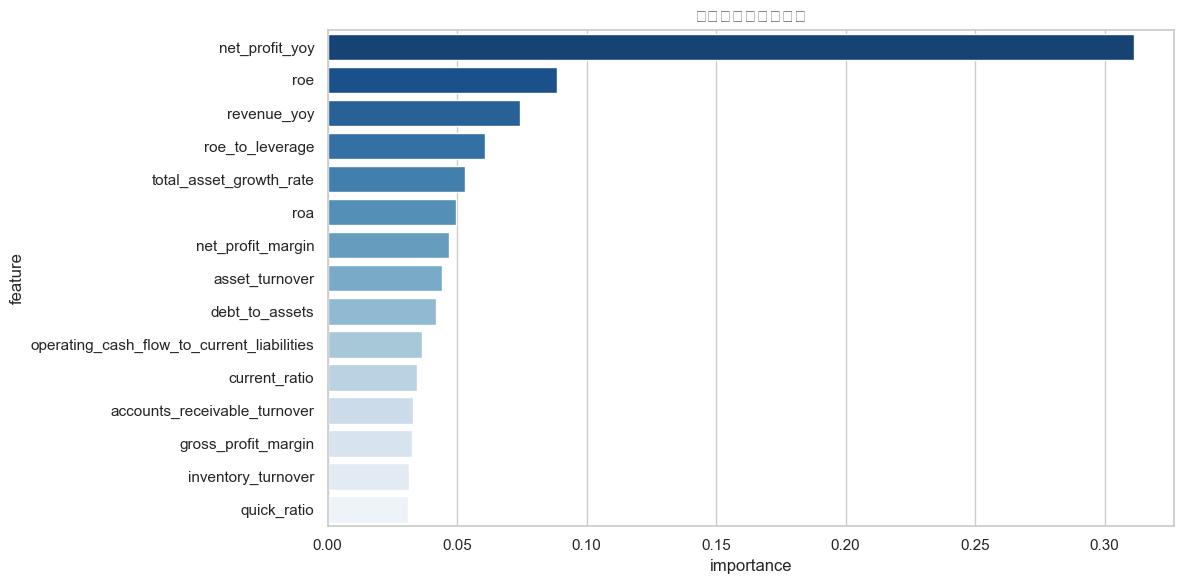

In [9]:
# 在测试集上计算预测概率与最终二分类结果（阈值 0.5），随后计算各项评估指标
test_proba = rf_pipeline.predict_proba(X_test)[:, 1] if len(X_test) else np.array([])
test_pred = (test_proba >= 0.5).astype(int) if len(X_test) else np.array([])

# 计算基本分类指标：准确率、精确率、召回率与 F1。若正负类均存在，计算 ROC AUC
metrics = {
    "accuracy": accuracy_score(y_test, test_pred) if len(X_test) else np.nan,
    "precision": precision_score(y_test, test_pred, zero_division=0) if len(X_test) else np.nan,
    "recall": recall_score(y_test, test_pred, zero_division=0) if len(X_test) else np.nan,
    "f1": f1_score(y_test, test_pred, zero_division=0) if len(X_test) else np.nan,
}
if len(X_test) and len(np.unique(y_test)) > 1:
    metrics["roc_auc"] = roc_auc_score(y_test, test_proba)
else:
    metrics["roc_auc"] = np.nan

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

print("测试集分类报告：")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, test_pred) if len(X_test) else np.array([[0, 0], [0, 0]])
cm_df = pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])
display(cm_df)

# 导出模型的特征重要性并展示前 20 个最重要的特征
feature_importance = pd.DataFrame({
    "feature": feature_candidates,
    "importance": rf_pipeline.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
display(feature_importance.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", palette="Blues_r")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.show()

### 9. 保存并生成预测模型

保存训练好的模型、特征列表、指标结果和必要的元数据，便于后续复用与部署。

In [10]:
# 保存训练好的流水线模型与特征说明文件，以便后续加载与复现
joblib.dump(rf_pipeline, MODEL_PATH)
with open(FEATURE_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "features": feature_candidates,
        "target_metric": TARGET_METRIC,
        "index_code": INDEX_CODE,
        "years": available_years,
        "metrics": metrics,
    }, f, ensure_ascii=False, indent=2)

print(f"模型已保存到：{MODEL_PATH}")
print(f"特征说明已保存到：{FEATURE_PATH}")

模型已保存到：outputs\hs300_rf_classifier.joblib
特征说明已保存到：outputs\hs300_rf_features.json


## 二、构建智能体

- 自动读取财务快照与模型输出；
- 调用大模型 API 生成正式分析报告；
- 支持基于同一上下文的多轮追问问答。

### 1. 智能体基础函数

In [11]:
from dataclasses import dataclass

if "AGENT_STATE" not in globals() or not isinstance(AGENT_STATE, dict):
    AGENT_STATE = {}

LOWER_BETTER_FEATURES = {"debt_to_assets"}


@dataclass
class AgentContext:
    company_input: str
    order_book_id: str
    company_name: str
    report_year: int
    improve_probability: float
    predicted_label: int
    target_metric: str
    snapshot: pd.DataFrame
    key_strengths: list[str]
    key_risks: list[str]


def _load_model_and_features() -> tuple[Pipeline, list[str]]:
    model = rf_pipeline if "rf_pipeline" in globals() and rf_pipeline is not None else None
    if model is None:
        if not MODEL_PATH.exists():
            raise FileNotFoundError("未找到模型，请先运行训练单元。")
        model = joblib.load(MODEL_PATH)

    features = feature_candidates if "feature_candidates" in globals() and isinstance(feature_candidates, list) and feature_candidates else None
    if features is None:
        if not FEATURE_PATH.exists():
            raise FileNotFoundError("未找到特征文件，请先运行训练单元。")
        with open(FEATURE_PATH, "r", encoding="utf-8") as f:
            features = json.load(f).get("features", [])

    if not features:
        raise ValueError("特征列表为空，无法预测。")
    return model, list(features)


def _default_report_year() -> int:
    if "raw_panel" in globals() and isinstance(raw_panel, pd.DataFrame) and not raw_panel.empty:
        return int(raw_panel["report_year"].max())
    if "END_YEAR" in globals():
        return int(END_YEAR)
    return int(pd.Timestamp.today().year - 1)


def search_company_candidates(company_query: str, topn: int = 10) -> pd.DataFrame:
    q = str(company_query).strip()
    if not q:
        raise ValueError("company_query 不能为空。")

    instruments = rqdatac.all_instruments(type="CS")
    if instruments is None or instruments.empty:
        raise ValueError("无法获取股票基础信息，请检查 rqdatac 连接。")

    cols = [c for c in ["order_book_id", "symbol", "abbrev_symbol", "display_name", "company_name", "short_name"] if c in instruments.columns]
    if not cols:
        raise ValueError("基础信息中缺少检索字段。")

    mask = pd.Series(False, index=instruments.index)
    q_upper = q.upper()
    for c in cols:
        val = instruments[c].astype(str)
        mask = mask | val.str.contains(q, case=False, na=False)
        if c == "order_book_id":
            mask = mask | val.str.upper().eq(q_upper)

    res = instruments.loc[mask].copy()
    if res.empty:
        raise ValueError(f"未匹配到公司：{company_query}")

    res["_score"] = 0
    if "order_book_id" in res.columns:
        res["_score"] += res["order_book_id"].astype(str).str.upper().eq(q_upper).astype(int) * 100
    for c in ["symbol", "abbrev_symbol", "display_name", "company_name", "short_name"]:
        if c in res.columns:
            v = res[c].astype(str)
            res["_score"] += v.str.contains(q, case=False, na=False).astype(int) * 5
            res["_score"] += v.str.upper().eq(q_upper).astype(int) * 40

    view_cols = [c for c in ["order_book_id", "symbol", "abbrev_symbol", "display_name", "company_name", "listed_date", "de_listed_date", "delisted_date", "_score"] if c in res.columns]
    return res.sort_values(["_score"], ascending=False).head(topn)[view_cols].reset_index(drop=True)


def _resolve_company(company_query: str) -> tuple[str, str, pd.DataFrame]:
    candidates = search_company_candidates(company_query, topn=10)
    top = candidates.iloc[0]
    order_book_id = str(top.get("order_book_id", "")).strip()
    if not order_book_id:
        raise ValueError("未能解析股票代码。")

    name_col = next((c for c in ["symbol", "display_name", "abbrev_symbol", "company_name"] if c in candidates.columns), "order_book_id")
    company_name = str(top[name_col])
    return order_book_id, company_name, candidates


def _fetch_company_snapshot(order_book_id: str, report_year: int) -> pd.DataFrame:
    frame = fetch_indicator_panel(report_year, [order_book_id])
    if frame.empty:
        raise ValueError(f"{order_book_id} 在 {report_year} 年未获取到财务数据。")

    frame = frame.copy()
    if "order_book_id" not in frame.columns:
        frame["order_book_id"] = order_book_id
    if "report_year" not in frame.columns:
        frame["report_year"] = report_year
    return frame.drop_duplicates(subset=["order_book_id", "report_year"], keep="last").iloc[[0]].copy()


def _summarize_metrics(snapshot: pd.DataFrame, features: list[str], reference_df: pd.DataFrame | None = None, topk: int = 3) -> tuple[list[str], list[str], pd.DataFrame]:
    row = snapshot.iloc[0]
    rows = []
    for col in features:
        if col not in snapshot.columns:
            continue
        value = row[col]
        if pd.isna(value):
            continue

        percentile = np.nan
        if reference_df is not None and col in reference_df.columns:
            ref = reference_df[col].replace([np.inf, -np.inf], np.nan).dropna()
            if not ref.empty:
                percentile = float((ref <= value).mean())

        score = percentile
        if col in LOWER_BETTER_FEATURES and not np.isnan(percentile):
            score = 1 - percentile

        rows.append({"feature": col, "value": float(value), "percentile": percentile, "score": score})

    metric_table = pd.DataFrame(rows)
    if metric_table.empty:
        return [], [], metric_table

    strengths = [
        f"{r.feature}: {r.value:.4f}（分位 {r.percentile:.1%}）"
        for r in metric_table.sort_values("score", ascending=False).head(topk).itertuples(index=False)
        if not np.isnan(r.percentile)
    ]
    risks = [
        f"{r.feature}: {r.value:.4f}（分位 {r.percentile:.1%}）"
        for r in metric_table.sort_values("score", ascending=True).head(topk).itertuples(index=False)
        if not np.isnan(r.percentile)
    ]
    return strengths, risks, metric_table


def build_api_agent_context(company_query: str, report_year: int | None = None, show_snapshot: bool = True) -> AgentContext:
    model, features = _load_model_and_features()
    order_book_id, company_name, candidates = _resolve_company(company_query)
    year = int(report_year) if report_year is not None else _default_report_year()

    snapshot = _fetch_company_snapshot(order_book_id, year)
    for c in features:
        if c not in snapshot.columns:
            snapshot[c] = np.nan

    X_input = snapshot[features].copy()
    improve_probability = float(model.predict_proba(X_input)[:, 1][0])
    predicted_label = int(improve_probability >= 0.5)

    reference_df = clean_df if "clean_df" in globals() and isinstance(clean_df, pd.DataFrame) else None
    strengths, risks, metric_table = _summarize_metrics(snapshot, features, reference_df=reference_df, topk=3)

    context = AgentContext(
        company_input=company_query,
        order_book_id=order_book_id,
        company_name=company_name,
        report_year=year,
        improve_probability=improve_probability,
        predicted_label=predicted_label,
        target_metric=TARGET_METRIC,
        snapshot=snapshot,
        key_strengths=strengths,
        key_risks=risks,
    )

    AGENT_STATE["api_context"] = context
    AGENT_STATE["candidates"] = candidates
    AGENT_STATE["metric_table"] = metric_table

    print("候选公司（前 10 条）：")
    display(candidates)

    if show_snapshot:
        cols = [c for c in ["order_book_id", "report_year", "roe", "roa", "net_profit_margin", "current_ratio", "quick_ratio", "debt_to_assets", TARGET_METRIC] if c in snapshot.columns]
        if cols:
            print("用于预测的财务快照：")
            display(snapshot[cols])

    return context

### 2. 智能体核心函数

In [12]:
# API 智能体核心：Deepseek SDK + 上下文序列化 + 报告生成 + 多轮追问
from openai import OpenAI
from getpass import getpass
import os

# 更安全做法：不在代码中硬编码密钥
DEEPSEEK_BASE = os.getenv("LLM_API_BASE", "https://api.deepseek.com")
LLM_MODEL = os.getenv("LLM_MODEL", "deepseek-chat")


def _get_api_key_securely() -> str:
    # 优先使用环境变量
    api_key = os.getenv("DEEPSEEK_API_KEY", os.getenv("LLM_API_KEY", os.getenv("OPENAI_API_KEY", "")))
    if api_key:
        return api_key

    # 无环境变量时，在当前会话中安全输入（不回显）
    entered = getpass("请输入 DEEPSEEK_API_KEY（输入过程不可见）: ").strip()
    if entered:
        # 仅保存到当前内核环境，不写入文件
        os.environ["DEEPSEEK_API_KEY"] = entered
        return entered

    raise ValueError("未检测到 LLM API Key。请设置 DEEPSEEK_API_KEY 或在提示时输入。")


def _llm_chat(messages: list[dict], temperature: float = 0.2, max_tokens: int = 1200) -> str:
    api_base = os.getenv("LLM_API_BASE", DEEPSEEK_BASE)
    model = os.getenv("LLM_MODEL", LLM_MODEL)
    api_key = _get_api_key_securely()

    client = OpenAI(api_key=api_key, base_url=api_base)
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
        stream=False,
    )

    choices = getattr(resp, "choices", None)
    if not choices or len(choices) == 0:
        raise RuntimeError("LLM API 返回为空，未获取到有效回答。")

    content = getattr(choices[0].message, "content", None)
    if not content:
        raise RuntimeError("LLM API 返回内容为空。")
    return content.strip()


def _to_jsonable(obj):
    if isinstance(obj, (pd.Timestamp, np.datetime64)):
        return str(pd.Timestamp(obj))
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray, list, tuple)):
        return [_to_jsonable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    return obj


def _build_llm_context_payload(ctx) -> dict:
    snapshot_row = ctx.snapshot.iloc[0].to_dict() if not ctx.snapshot.empty else {}
    metric_table = AGENT_STATE.get("metric_table")
    metric_records = []
    if isinstance(metric_table, pd.DataFrame) and not metric_table.empty:
        metric_records = metric_table.sort_values("score", ascending=False).head(12).to_dict(orient="records")

    payload = {
        "company_input": ctx.company_input,
        "company_name": ctx.company_name,
        "order_book_id": ctx.order_book_id,
        "report_year": ctx.report_year,
        "target_metric": ctx.target_metric,
        "improve_probability": round(ctx.improve_probability, 6),
        "predicted_label": ctx.predicted_label,
        "key_strengths": ctx.key_strengths,
        "key_risks": ctx.key_risks,
        "snapshot": snapshot_row,
        "top_metrics": metric_records,
    }
    return _to_jsonable(payload)


def run_financial_agent_with_api(company_query: str, report_year: int | None = None):
    if "build_api_agent_context" not in globals():
        raise NameError("缺少 build_api_agent_context，请先运行第23个单元。")

    ctx = build_api_agent_context(company_query=company_query, report_year=report_year, show_snapshot=True)
    payload = _build_llm_context_payload(ctx)

    system_prompt = (
        "你是A股财务分析智能体。"
        "你必须基于提供的数据进行分析，不得编造不存在的财务指标。"
        "输出结构：\n"
        "1) 一句话结论\n"
        "2) 核心依据（3-5条）\n"
        "3) 风险提示（2-4条）\n"
        "4) 可执行建议（3条）\n"
        "5) 结论置信说明（结合模型概率）"
    )
    user_prompt = (
        "请基于以下 JSON 数据输出正式报告，使用中文，避免空话：\n"
        f"{json.dumps(payload, ensure_ascii=False, indent=2, default=str)}"
    )

    api_report = _llm_chat(
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.2,
        max_tokens=1400,
    )

    AGENT_STATE["api_context"] = ctx
    AGENT_STATE["api_system_prompt"] = system_prompt
    AGENT_STATE["api_payload"] = payload
    AGENT_STATE["api_chat_history"] = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": api_report},
    ]

    print("【API 智能体报告】")
    print(api_report)
    return ctx, api_report


def ask_financial_agent_api(question: str) -> str:
    question = str(question).strip()
    if not question:
        raise ValueError("question 不能为空。")

    if "api_chat_history" not in AGENT_STATE:
        raise ValueError("请先运行 run_financial_agent_with_api('公司名') 初始化 API 智能体上下文。")

    payload = AGENT_STATE.get("api_payload", {})
    context_prompt = (
        "以下是你必须遵守的上下文（JSON）：\n"
        f"{json.dumps(payload, ensure_ascii=False, default=str)}\n"
        "回答要求：只基于上下文，不编造；如果上下文不足，明确指出。"
    )

    chat_history = AGENT_STATE.get("api_chat_history", [])
    recent_turns = chat_history[-8:] if len(chat_history) > 8 else chat_history
    messages = list(recent_turns)
    messages.append({"role": "system", "content": context_prompt})
    messages.append({"role": "user", "content": question})

    answer = _llm_chat(messages=messages, temperature=0.2, max_tokens=450)

    AGENT_STATE["api_chat_history"].append({"role": "user", "content": question})
    AGENT_STATE["api_chat_history"].append({"role": "assistant", "content": answer})
    return answer

### 3. 智能体交互

下面这个演示单元会显式展示智能体流程：公司识别、财务快照获取、模型预测、API 报告生成、追问问答。运行后会直接在单元输出里看到全过程。

In [13]:
# 输入公司名后启动 API 智能体，并支持连续追问（输入 exit/quit/退出 结束）

company_query = input("请输入公司名或股票名（例如：贵州茅台）：").strip()

try:
    required_symbols = [
        "fetch_indicator_panel",
        "build_api_agent_context",
        "run_financial_agent_with_api",
        "ask_financial_agent_api",
    ]
    missing = [s for s in required_symbols if s not in globals()]
    if missing:
        raise NameError(f"缺少依赖定义: {missing}。请先按提示顺序运行前置单元。")

    print("[1/3] 识别公司并抓取财务快照...")
    print("[2/3] 执行随机森林预测并调用 Deepseek 生成报告...")
    print("[3/3] 进入连续追问模式（输入 exit/quit/退出 结束）...\n")

    api_ctx, api_report = run_financial_agent_with_api(company_query)

    while True:
        follow_up = input("追问> ").strip()
        if follow_up.lower() in {"exit", "quit", "q"} or follow_up in {"退出", "结束", "停止"}:
            print("已结束追问。")
            break
        if not follow_up:
            continue

        answer = ask_financial_agent_api(follow_up)
        print("\n--- 对话回合 ---")
        print(f"Ask: {follow_up}")
        print("Answer:")
        print(answer)
        print()

except Exception as exc:
    print("智能体演示暂不可用：", exc)
    print("提示：请先配置 DEEPSEEK_API_KEY，并按顺序运行第6、8、23、24个单元后再执行本单元。")

[1/3] 识别公司并抓取财务快照...
[2/3] 执行随机森林预测并调用 Deepseek 生成报告...
[3/3] 进入连续追问模式（输入 exit/quit/退出 结束）...

候选公司（前 10 条）：


,order_book_id,symbol,abbrev_symbol,listed_date,de_listed_date,_score
0,688670.XSHG,金迪克,JDK,2021-08-02,0000-00-00,45


用于预测的财务快照：


,order_book_id,report_year,roe,roa,net_profit_margin,current_ratio,quick_ratio,debt_to_assets,net_profit_yoy
0,688670.XSHG,2025,-0.10189,-0.10685,-1.085371,2.462177,2.167103,0.168065,NaN


【API 智能体报告】
1) **一句话结论**  
基于模型预测，金迪克（688670.XSHG）在2025年净利润同比增长（net_profit_yoy）改善的概率为49.83%，模型预测结果为“不改善”（predicted_label=0），显示其盈利修复面临较大不确定性。

2) **核心依据**  
- **营收增长强劲**：营业收入同比增长率（revenue_yoy）为121.40%，分位值高达98.2%，表明公司收入端扩张显著。  
- **毛利率维持高位**：毛利率（gross_profit_margin）为63.42%，分位值90.2%，反映产品盈利能力较强。  
- **财务结构稳健**：资产负债率（debt_to_assets）仅16.81%，分位值5.4%，偿债压力极低；流动比率（2.46）和速动比率（2.17）均处于健康水平。  

3) **风险提示**  
- **盈利质量严重恶化**：净资产收益率（ROE）为-10.19%、总资产收益率（ROA）为-10.68%、净利润率（net_profit_margin）为-108.54%，三项指标分位值均为0%，显示公司处于实质性亏损状态。  
- **营运效率低下**：总资产周转率（0.078）和存货周转率（0.706）分位值均低于15%，资产使用效率差；经营活动现金流对流动负债的覆盖率为-63.65%，现金流承压。  
- **增长动力不足**：总资产增长率为-5.42%，分位值仅1.6%，资产规模收缩可能限制业务扩张潜力。  

4) **可执行建议**  
- **聚焦盈利转化**：优先分析营收高增长未能转化为净利润的原因（如费用激增或非经常性损失），针对性优化成本结构。  
- **提升资产运营效率**：审视存货与应收账款管理（应收账款周转率仅1.15），加速资金回流以改善现金流。  
- **审慎评估投资时机**：鉴于模型对盈利改善的预测概率低于50%，建议结合行业政策与季度财报验证盈利拐点信号后再做配置决策。  

5) **结论置信说明**  
- 模型预测净利润同比增长改善的概率为49.83%，接近随机水平（50%），置信度较低。  
- 预测主要依赖历史财务指标，但公司核心盈利指标（ROE、净利润率）均处于行业底部分位，且净利润同比数据缺失（NaN），可能影响模型对盈利趋势的